In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch import nn
from torch import optim
from torch.optim import lr_scheduler # Import lr_scheduler
from torch.utils.data import TensorDataset, Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler

KeyboardInterrupt: 

In [ ]:
!wget "https://drive.google.com/uc?export=download&id=12X6DEdfMB99GPJpWAgORZrlEuuc5uIEk" -O "dataA3.zip"
!unzip -q dataA3.zip #unzip :)

In [ ]:
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("GPU is used" if torch.cuda.is_available() else "GPU not available: try to switch to GPU for faster computation")

GPU not available: try to switch to GPU for faster computation


In [ ]:
metadata = pd.read_csv("Assign3/data/selected_equations_metadata.csv", index_col="safe_name")
metadata

,equation,formula,difficulty,n_variables,variables,lows,highs,n_train,n_val,n_test
safe_name,,,,,,,,,,
I_6_2,I.6.2,exp(-(theta/sigma)**2/2)/(sqrt(2*pi)*sigma),easy,2,"sigma, theta","1.0, 1.0","3.0, 3.0",10000,2000,2000
I_14_3,I.14.3,m*g*z,easy,3,"m, g, z","1.0, 1.0, 1.0","5.0, 5.0, 5.0",10000,2000,2000
I_18_4,I.18.4,(m1*r1+m2*r2)/(m1+m2),medium,4,"m1, m2, r1, r2","1.0, 1.0, 1.0, 1.0","5.0, 5.0, 5.0, 5.0",10000,2000,2000
I_29_16,I.29.16,sqrt(x1**2+x2**2-2*x1*x2*cos(theta1-theta2)),medium,4,"x1, x2, theta1, theta2","1.0, 1.0, 1.0, 1.0","5.0, 5.0, 5.0, 5.0",10000,2000,2000
I_9_18,I.9.18,G*m1*m2/((x2-x1)**2+(y2-y1)**2+(z2-z1)**2),hard,9,"m1, m2, G, x1, x2, y1, y2, z1, z2","1.0, 1.0, 1.0, 3.0, 1.0, 3.0, 1.0, 3.0, 1.0","2.0, 2.0, 2.0, 4.0, 2.0, 4.0, 2.0, 4.0, 2.0",10000,2000,2000


In [ ]:
# The data loading logic has been moved to cell WflfuAFCuNgm to facilitate iterating over all equations.

In [ ]:
#set up MLP
#Layers are n_vars -> base_width -> 2*base_width -> 4*base_width -> output

class MLP(nn.Module):
    def __init__(self, n_vars, base_width):
        super(MLP, self).__init__()
        # Define layer widths based on base_width
        width1 = base_width
        width2 = base_width * 2
        width3 = base_width * 4

        self.mlp_layer = nn.Sequential(
            nn.Linear(n_vars, width1),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(width1, width2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(width2, width3),
            nn.BatchNorm1d(width3),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(width3, 1)
        )

    def forward(self, x):
        return self.mlp_layer(x)

In [ ]:
mlp_widths = [64, 128, 256]
num_seeds = 5 # Number of seeds for stability analysis
all_experiments_results = {} # Stores results for (equation, width, seed)

# Loop through each equation in the metadata
for eqn_name in metadata.index:
    print(f"\n--- Processing Equation: {eqn_name} ---")
    all_experiments_results[eqn_name] = {}

    # Get n_vars for the current equation
    n_vars = metadata.loc[[eqn_name], ["n_variables"]]["n_variables"].item()

    # Create dataloaders for the current equation
    train_data = pd.read_csv("Assign3/data/" + eqn_name + "/train_clean.csv").to_numpy().astype(np.float32)
    test_data = pd.read_csv("Assign3/data/" + eqn_name + "/test_clean.csv").to_numpy().astype(np.float32)
    val_data = pd.read_csv("Assign3/data/" + eqn_name + "/val_clean.csv").to_numpy().astype(np.float32)

    x_train = train_data[:, :n_vars]
    y_train = train_data[:, n_vars]
    x_val = val_data[:, :n_vars]
    y_val = val_data[:, n_vars]
    x_test = test_data[:, :n_vars]
    y_test = test_data[:, n_vars]

    # Normalize the target variable (y) using MinMaxScaler
    # Fit scaler only on training data to prevent data leakage
    y_scaler = MinMaxScaler()
    y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten().astype(np.float32)
    y_val_scaled = y_scaler.transform(y_val.reshape(-1, 1)).flatten().astype(np.float32)
    y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).flatten().astype(np.float32)

    train_dataset = TensorDataset(torch.tensor(x_train), torch.tensor(y_train_scaled))
    val_dataset = TensorDataset(torch.tensor(x_val), torch.tensor(y_val_scaled))
    test_dataset = TensorDataset(torch.tensor(x_test), torch.tensor(y_test_scaled))

    batch_size = 32
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    # Loop through MLP widths
    for width in mlp_widths:
        all_experiments_results[eqn_name][width] = [] # List to store results for each seed

        # Loop through seeds for stability analysis
        for seed in range(num_seeds):
            print(f"\nTraining MLP for Equation: {eqn_name}, Width: {width}, Seed: {seed+1}/{num_seeds}")

            # Set random seeds for reproducibility
            torch.manual_seed(seed)
            np.random.seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)

            # Model initialization, optimizer, scheduler (re-initialize for each seed)
            model = MLP(n_vars, base_width=width)
            model = model.to(device)
            model = model.float() # Cast model parameters to float32
            criterion = nn.MSELoss()
            optimiser = optim.Adam(model.parameters(), lr=1e-3) # Reduced learning rate
            scheduler = lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=5) # Learning rate scheduler
            num_epochs = 50

            train_losses = []
            val_losses = []

            for epoch in range(num_epochs):
                model.train()
                for inputs, values in train_loader:
                    inputs = inputs.to(device)
                    values = values.to(device)

                    y_pred = model(inputs).flatten()
                    optimiser.zero_grad()
                    train_loss = criterion(y_pred, values)
                    train_loss.backward()
                    optimiser.step()

                model.eval()
                with torch.no_grad():
                    epoch_val_losses = []
                    for inputs, values in val_loader:
                        inputs = inputs.to(device)
                        values = values.to(device)

                        y_pred = model(inputs).flatten()
                        val_loss = criterion(y_pred, values)
                        epoch_val_losses.append(val_loss.item())
                    val_loss_epoch_avg = np.mean(epoch_val_losses)

                scheduler.step(val_loss_epoch_avg) # Update the learning rate scheduler

                if (epoch + 1) % 10 == 0 or epoch == 1: # Print less frequently
                    print(f"Epoch [{epoch+1}/{num_epochs}], training loss: {train_loss.item():.6f}, validation loss: {val_loss_epoch_avg:.6f}")
                train_losses.append(train_loss.item())
                val_losses.append(val_loss_epoch_avg)

            # Evaluate on the clean test set
            model.eval()
            with torch.no_grad():
                y_test_pred = model(torch.tensor(x_test).to(device)).flatten()
                test_loss = criterion(y_test_pred, torch.tensor(y_test_scaled).to(device)) # Evaluate against scaled y_test
                final_test_mse = test_loss.item()

            print(f"Final Test MSE for {eqn_name}, Width {width}, Seed {seed+1}: {final_test_mse:.6f}")

            # Store results for this specific run (seed)
            all_experiments_results[eqn_name][width].append({
                'seed': seed,
                'train_losses': train_losses,
                'val_losses': val_losses,
                'final_test_mse': final_test_mse
            })



--- Processing Equation: I_6_2 ---

Training MLP for Equation: I_6_2, Width: 64, Seed: 1/5
Epoch [2/50], training loss: 0.008786, validation loss: 0.006898
Epoch [10/50], training loss: 0.006774, validation loss: 0.000854
Epoch [20/50], training loss: 0.002182, validation loss: 0.006713
Epoch [30/50], training loss: 0.000757, validation loss: 0.006326
Epoch [40/50], training loss: 0.005058, validation loss: 0.007436
Epoch [50/50], training loss: 0.000990, validation loss: 0.006870
Final Test MSE for I_6_2, Width 64, Seed 1: 0.007097

Training MLP for Equation: I_6_2, Width: 64, Seed: 2/5
Epoch [2/50], training loss: 0.002644, validation loss: 0.009467
Epoch [10/50], training loss: 0.001922, validation loss: 0.002419
Epoch [20/50], training loss: 0.001284, validation loss: 0.004430
Epoch [30/50], training loss: 0.001418, validation loss: 0.003858
Epoch [40/50], training loss: 0.002589, validation loss: 0.005390
Epoch [50/50], training loss: 0.002526, validation loss: 0.003549
Final Tes

In [ ]:
num_equations = len(all_experiments_results)
# Adjust figure size for better readability with multiple subplots
fig, axes = plt.subplots(num_equations, 1, figsize=(14, 7 * num_equations), squeeze=False)

colors = ['blue', 'red', 'green', 'purple', 'orange'] # Colors for different widths

for i, (eqn_name, equation_results) in enumerate(all_experiments_results.items()):
    ax = axes[i, 0]
    ax.set_title(f'Training and Validation Losses for Equation: {eqn_name} (Representative Seed 0)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')

    for j, (width, seed_results_list) in enumerate(equation_results.items()):
        # Plot only for a representative seed (e.g., the first seed, index 0)
        if seed_results_list: # Ensure there are results for this width
            representative_run = seed_results_list[0] # Get results for seed 0
            train_losses = representative_run['train_losses']
            val_losses = representative_run['val_losses']

            color_idx = j % len(colors)
            ax.plot(np.arange(0, len(val_losses)), val_losses, color=colors[color_idx], linestyle='-', label=f'Val Loss (Width {width})')
            ax.plot(np.arange(0, len(train_losses)), train_losses, color=colors[color_idx], linestyle='--', label=f'Train Loss (Width {width})')

    ax.tick_params(axis='y')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Step 3: Stability Analysis - Distribution of Test MSE and Divergence

In [ ]:
# Plotting the distribution of test MSE across seeds

fig, axes = plt.subplots(len(all_experiments_results), len(mlp_widths), figsize=(18, 5 * len(all_experiments_results)), squeeze=False)
divergence_threshold = 1.0 # Define a threshold for divergence (e.g., MSE > 1.0 after y-scaling)

print("\n--- Stability Analysis Results ---")

for i, (eqn_name, equation_results) in enumerate(all_experiments_results.items()):
    for j, (width, seed_results_list) in enumerate(equation_results.items()):
        test_mses = [res['final_test_mse'] for res in seed_results_list]

        ax = axes[i, j]
        ax.hist(test_mses, bins=5, edgecolor='black')
        ax.set_title(f'{eqn_name}, Width {width}')
        ax.set_xlabel('Test MSE')
        ax.set_ylabel('Frequency')

        # Calculate and report divergence
        diverged_seeds = [mse for mse in test_mses if mse > divergence_threshold]
        fraction_diverged = len(diverged_seeds) / len(test_mses)
        print(f"Equation: {eqn_name}, Width: {width} | Avg Test MSE: {np.mean(test_mses):.4f} | Fraction Diverged (MSE > {divergence_threshold}): {fraction_diverged:.2f}")

plt.tight_layout()
plt.show()

### Step 4: Noise Robustness Analysis

In [ ]:
noise_std_devs = [0, 0.01, 0.05, 0.1] # Standard deviations for Gaussian noise
all_noise_experiments_results = {}
mlp_widths = [256]
num_seeds = 5 # Number of seeds for stability analysis
# Loop through each equation in the metadata
for eqn_name in metadata.index:
    print(f"\n--- Processing Equation (Noise Robustness): {eqn_name} ---")
    all_noise_experiments_results[eqn_name] = {}

    # Get n_vars for the current equation
    n_vars = metadata.loc[[eqn_name], ["n_variables"]]["n_variables"].item()

    # Load original clean data (only once per equation)
    train_data_clean = pd.read_csv("Assign3/data/" + eqn_name + "/train_clean.csv").to_numpy().astype(np.float32)
    test_data_clean = pd.read_csv("Assign3/data/" + eqn_name + "/test_clean.csv").to_numpy().astype(np.float32)
    val_data_clean = pd.read_csv("Assign3/data/" + eqn_name + "/val_clean.csv").to_numpy().astype(np.float32)

    x_train_clean = train_data_clean[:, :n_vars]
    y_train_clean = train_data_clean[:, n_vars]
    x_val_clean = val_data_clean[:, :n_vars]
    y_val_clean = val_data_clean[:, n_vars]
    x_test_clean = test_data_clean[:, :n_vars]
    y_test_clean = test_data_clean[:, n_vars]

    # Normalize the target variable (y) using MinMaxScaler (fit on clean training data)
    y_scaler = MinMaxScaler()
    y_train_scaled_clean = y_scaler.fit_transform(y_train_clean.reshape(-1, 1)).flatten().astype(np.float32)
    y_val_scaled_clean = y_scaler.transform(y_val_clean.reshape(-1, 1)).flatten().astype(np.float32)
    y_test_scaled_clean = y_scaler.transform(y_test_clean.reshape(-1, 1)).flatten().astype(np.float32)

    # Loop through MLP widths
    for width in mlp_widths:
        all_noise_experiments_results[eqn_name][width] = {}

        # Loop through noise levels
        for noise_std_dev in noise_std_devs:
            all_noise_experiments_results[eqn_name][width][noise_std_dev] = [] # List to store results for each seed

            print(f"\nTraining MLP for Equation: {eqn_name}, Width: {width}, Noise Std Dev: {noise_std_dev}")

            # Apply noise to training targets (y_train_scaled_clean) for this noise_std_dev
            if noise_std_dev > 0:
                noise = np.random.normal(0, noise_std_dev, y_train_scaled_clean.shape).astype(np.float32)
                y_train_scaled_noisy = y_train_scaled_clean + noise
            else:
                y_train_scaled_noisy = y_train_scaled_clean # No noise for std_dev = 0

            # Create dataloaders for the current noise level (using noisy training data)
            train_dataset_noisy = TensorDataset(torch.tensor(x_train_clean), torch.tensor(y_train_scaled_noisy))
            val_dataset_clean = TensorDataset(torch.tensor(x_val_clean), torch.tensor(y_val_scaled_clean))
            test_dataset_clean = TensorDataset(torch.tensor(x_test_clean), torch.tensor(y_test_scaled_clean))

            batch_size = 32
            train_loader_noisy = DataLoader(train_dataset_noisy, batch_size=batch_size, shuffle=True)
            val_loader_clean = DataLoader(val_dataset_clean, batch_size=batch_size)
            test_loader_clean = DataLoader(test_dataset_clean, batch_size=batch_size)

            # Loop through seeds for stability analysis (inside noise loop)
            for seed in range(num_seeds):
                print(f"    Seed: {seed+1}/{num_seeds}")

                # Set random seeds for reproducibility
                torch.manual_seed(seed)
                np.random.seed(seed)
                if torch.cuda.is_available():
                    torch.cuda.manual_seed_all(seed)

                # Model initialization, optimizer, scheduler (re-initialize for each seed and noise level)
                model = MLP(n_vars, base_width=width)
                model = model.to(device)
                model = model.float() # Cast model parameters to float32
                criterion = nn.MSELoss()
                optimiser = optim.Adam(model.parameters(), lr=1e-3)
                scheduler = lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=5)
                num_epochs = 50

                for epoch in range(num_epochs):
                    model.train()
                    for inputs, values in train_loader_noisy:
                        inputs = inputs.to(device)
                        values = values.to(device)

                        y_pred = model(inputs).flatten()
                        optimiser.zero_grad()
                        train_loss = criterion(y_pred, values)
                        train_loss.backward()
                        optimiser.step()

                    model.eval()
                    with torch.no_grad():
                        epoch_val_losses = []
                        for inputs, values in val_loader_clean:
                            inputs = inputs.to(device)
                            values = values.to(device)

                            y_pred = model(inputs).flatten()
                            val_loss = criterion(y_pred, values)
                            epoch_val_losses.append(val_loss.item())
                        val_loss_epoch_avg = np.mean(epoch_val_losses)

                    scheduler.step(val_loss_epoch_avg)

                # Evaluate on the clean test set (important for noise robustness analysis)
                model.eval()
                with torch.no_grad():
                    y_test_pred = model(torch.tensor(x_test_clean).to(device)).flatten()
                    # Evaluate against scaled y_test_clean, not noisy
                    test_loss = criterion(y_test_pred, torch.tensor(y_test_scaled_clean).to(device))
                    final_test_mse = test_loss.item()

                print(f"        Final Clean Test MSE for Noise {noise_std_dev}, Seed {seed+1}: {final_test_mse:.6f}")

                # Store results for this specific run (seed and noise level)
                all_noise_experiments_results[eqn_name][width][noise_std_dev].append({
                    'seed': seed,
                    'final_test_mse_clean': final_test_mse
                })



--- Processing Equation (Noise Robustness): I_6_2 ---

Training MLP for Equation: I_6_2, Width: 256, Noise Std Dev: 0
    Seed: 1/5
        Final Clean Test MSE for Noise 0, Seed 1: 0.000138
    Seed: 2/5
        Final Clean Test MSE for Noise 0, Seed 2: 0.000163
    Seed: 3/5
        Final Clean Test MSE for Noise 0, Seed 3: 0.000105
    Seed: 4/5
        Final Clean Test MSE for Noise 0, Seed 4: 0.000051
    Seed: 5/5
        Final Clean Test MSE for Noise 0, Seed 5: 0.000129

Training MLP for Equation: I_6_2, Width: 256, Noise Std Dev: 0.01
    Seed: 1/5
        Final Clean Test MSE for Noise 0.01, Seed 1: 0.000064
    Seed: 2/5
        Final Clean Test MSE for Noise 0.01, Seed 2: 0.000120
    Seed: 3/5
        Final Clean Test MSE for Noise 0.01, Seed 3: 0.000087
    Seed: 4/5
        Final Clean Test MSE for Noise 0.01, Seed 4: 0.000156
    Seed: 5/5
        Final Clean Test MSE for Noise 0.01, Seed 5: 0.000103

Training MLP for Equation: I_6_2, Width: 256, Noise Std Dev: 0.05
  

In [ ]:
import pickle

In [ ]:
#Very scuffed way to get all my data loaded lol
with open('width_256_noisedict.pickle', 'rb') as handle:
    test1 = pickle.load(handle)
print(test1)
with open('width_128_noisedict.pickle', 'rb') as handle:
    test2 = pickle.load(handle)
print(test2)
with open('width_64_noisedict.pickle', 'rb') as handle:
    test3 = pickle.load(handle)
print(test3)

mergetest = {**test1, **test2, **test3}
print(mergetest)

{'I_6_2': {256: {0: [{'seed': 0, 'final_test_mse_clean': 0.0001378118759021163}, {'seed': 1, 'final_test_mse_clean': 0.00016302833682857454}, {'seed': 2, 'final_test_mse_clean': 0.00010496202594367787}, {'seed': 3, 'final_test_mse_clean': 5.070810584584251e-05}, {'seed': 4, 'final_test_mse_clean': 0.00012918259017169476}], 0.01: [{'seed': 0, 'final_test_mse_clean': 6.400081474566832e-05}, {'seed': 1, 'final_test_mse_clean': 0.00011990807252004743}, {'seed': 2, 'final_test_mse_clean': 8.692366100149229e-05}, {'seed': 3, 'final_test_mse_clean': 0.00015591429837513715}, {'seed': 4, 'final_test_mse_clean': 0.00010314599057892337}], 0.05: [{'seed': 0, 'final_test_mse_clean': 0.00011407293641241267}, {'seed': 1, 'final_test_mse_clean': 0.00017329091497231275}, {'seed': 2, 'final_test_mse_clean': 0.00010736648255260661}, {'seed': 3, 'final_test_mse_clean': 0.00011308774264762178}, {'seed': 4, 'final_test_mse_clean': 8.877900108927861e-05}], 0.1: [{'seed': 0, 'final_test_mse_clean': 0.00015690

In [ ]:
all_noise_experiments_results = {'I_6_2': {256: {0: [{'seed': 0, 'final_test_mse_clean': 0.0001378118759021163}, {'seed': 1, 'final_test_mse_clean': 0.00016302833682857454}, {'seed': 2, 'final_test_mse_clean': 0.00010496202594367787}, {'seed': 3, 'final_test_mse_clean': 5.070810584584251e-05}, {'seed': 4, 'final_test_mse_clean': 0.00012918259017169476}], 0.01: [{'seed': 0, 'final_test_mse_clean': 6.400081474566832e-05}, {'seed': 1, 'final_test_mse_clean': 0.00011990807252004743}, {'seed': 2, 'final_test_mse_clean': 8.692366100149229e-05}, {'seed': 3, 'final_test_mse_clean': 0.00015591429837513715}, {'seed': 4, 'final_test_mse_clean': 0.00010314599057892337}], 0.05: [{'seed': 0, 'final_test_mse_clean': 0.00011407293641241267}, {'seed': 1, 'final_test_mse_clean': 0.00017329091497231275}, {'seed': 2, 'final_test_mse_clean': 0.00010736648255260661}, {'seed': 3, 'final_test_mse_clean': 0.00011308774264762178}, {'seed': 4, 'final_test_mse_clean': 8.877900108927861e-05}], 0.1: [{'seed': 0, 'final_test_mse_clean': 0.00015690807776991278}, {'seed': 1, 'final_test_mse_clean': 8.421780512435362e-05}, {'seed': 2, 'final_test_mse_clean': 0.00019429880194365978}, {'seed': 3, 'final_test_mse_clean': 0.00014822201046627015}, {'seed': 4, 'final_test_mse_clean': 0.00020019974908791482}]}, 128: {0: [{'seed': 0, 'final_test_mse_clean': 0.0013113244203850627}, {'seed': 1, 'final_test_mse_clean': 0.0025499265175312757}, {'seed': 2, 'final_test_mse_clean': 0.0012425135355442762}, {'seed': 3, 'final_test_mse_clean': 0.0023921732790768147}, {'seed': 4, 'final_test_mse_clean': 0.0021058358252048492}], 0.01: [{'seed': 0, 'final_test_mse_clean': 0.0012687353882938623}, {'seed': 1, 'final_test_mse_clean': 0.0021434251684695482}, {'seed': 2, 'final_test_mse_clean': 0.0012324928538873792}, {'seed': 3, 'final_test_mse_clean': 0.002557154977694154}, {'seed': 4, 'final_test_mse_clean': 0.002340236445888877}], 0.05: [{'seed': 0, 'final_test_mse_clean': 0.001050072256475687}, {'seed': 1, 'final_test_mse_clean': 0.0009999488247558475}, {'seed': 2, 'final_test_mse_clean': 0.0010842536576092243}, {'seed': 3, 'final_test_mse_clean': 0.0015818217070773244}, {'seed': 4, 'final_test_mse_clean': 0.001836755545809865}], 0.1: [{'seed': 0, 'final_test_mse_clean': 0.00010238795221084729}, {'seed': 1, 'final_test_mse_clean': 0.000696114671882242}, {'seed': 2, 'final_test_mse_clean': 0.00034876741119660437}, {'seed': 3, 'final_test_mse_clean': 0.00028238078812137246}, {'seed': 4, 'final_test_mse_clean': 0.0012200891505926847}]}, 64: {0: [{'seed': 0, 'final_test_mse_clean': 0.006592403631657362}, {'seed': 1, 'final_test_mse_clean': 0.0038246200419962406}, {'seed': 2, 'final_test_mse_clean': 0.005092076025903225}, {'seed': 3, 'final_test_mse_clean': 0.0031350874342024326}, {'seed': 4, 'final_test_mse_clean': 0.005076648201793432}], 0.01: [{'seed': 0, 'final_test_mse_clean': 0.007394825108349323}, {'seed': 1, 'final_test_mse_clean': 0.005763907916843891}, {'seed': 2, 'final_test_mse_clean': 0.005234110169112682}, {'seed': 3, 'final_test_mse_clean': 0.004100525751709938}, {'seed': 4, 'final_test_mse_clean': 0.004702683538198471}], 0.05: [{'seed': 0, 'final_test_mse_clean': 0.005056451540440321}, {'seed': 1, 'final_test_mse_clean': 0.004869723226875067}, {'seed': 2, 'final_test_mse_clean': 0.0034047907683998346}, {'seed': 3, 'final_test_mse_clean': 0.003144002053886652}, {'seed': 4, 'final_test_mse_clean': 0.0034394930116832256}], 0.1: [{'seed': 0, 'final_test_mse_clean': 0.004607591778039932}, {'seed': 1, 'final_test_mse_clean': 0.004334304016083479}, {'seed': 2, 'final_test_mse_clean': 0.0021073981188237667}, {'seed': 3, 'final_test_mse_clean': 0.0025301342830061913}, {'seed': 4, 'final_test_mse_clean': 0.0021859966218471527}]}},

'I_14_3': {256: {0: [{'seed': 0, 'final_test_mse_clean': 0.045089252293109894}, {'seed': 1, 'final_test_mse_clean': 0.04769253358244896}, {'seed': 2, 'final_test_mse_clean': 0.043401069939136505}, {'seed': 3, 'final_test_mse_clean': 0.04311896860599518}, {'seed': 4, 'final_test_mse_clean': 0.04120887443423271}], 0.01: [{'seed': 0, 'final_test_mse_clean': 0.037539683282375336}, {'seed': 1, 'final_test_mse_clean': 0.03980223834514618}, {'seed': 2, 'final_test_mse_clean': 0.042525842785835266}, {'seed': 3, 'final_test_mse_clean': 0.04262373223900795}, {'seed': 4, 'final_test_mse_clean': 0.04177362844347954}], 0.05: [{'seed': 0, 'final_test_mse_clean': 0.032805781811475754}, {'seed': 1, 'final_test_mse_clean': 0.045661184936761856}, {'seed': 2, 'final_test_mse_clean': 0.038944393396377563}, {'seed': 3, 'final_test_mse_clean': 0.04018453136086464}, {'seed': 4, 'final_test_mse_clean': 0.037454213947057724}], 0.1: [{'seed': 0, 'final_test_mse_clean': 0.024696500971913338}, {'seed': 1, 'final_test_mse_clean': 0.030017919838428497}, {'seed': 2, 'final_test_mse_clean': 0.008171537891030312}, {'seed': 3, 'final_test_mse_clean': 0.03377166762948036}, {'seed': 4, 'final_test_mse_clean': 0.023227665573358536}]}, 128: {0: [{'seed': 0, 'final_test_mse_clean': 0.045954491943120956}, {'seed': 1, 'final_test_mse_clean': 0.030916772782802582}, {'seed': 2, 'final_test_mse_clean': 0.0044863843359053135}, {'seed': 3, 'final_test_mse_clean': 0.03644903749227524}, {'seed': 4, 'final_test_mse_clean': 0.035706039518117905}], 0.01: [{'seed': 0, 'final_test_mse_clean': 0.03717997297644615}, {'seed': 1, 'final_test_mse_clean': 0.03264646232128143}, {'seed': 2, 'final_test_mse_clean': 0.006354419514536858}, {'seed': 3, 'final_test_mse_clean': 0.032390035688877106}, {'seed': 4, 'final_test_mse_clean': 0.03622141852974892}], 0.05: [{'seed': 0, 'final_test_mse_clean': 0.0420120507478714}, {'seed': 1, 'final_test_mse_clean': 0.04647958278656006}, {'seed': 2, 'final_test_mse_clean': 0.006979352328926325}, {'seed': 3, 'final_test_mse_clean': 0.03160436823964119}, {'seed': 4, 'final_test_mse_clean': 0.04024730622768402}], 0.1: [{'seed': 0, 'final_test_mse_clean': 0.036525461822748184}, {'seed': 1, 'final_test_mse_clean': 0.04474126175045967}, {'seed': 2, 'final_test_mse_clean': 0.028165433555841446}, {'seed': 3, 'final_test_mse_clean': 0.03250659629702568}, {'seed': 4, 'final_test_mse_clean': 0.036072224378585815}]}, 64: {0: [{'seed': 0, 'final_test_mse_clean': 0.032339923083782196}, {'seed': 1, 'final_test_mse_clean': 0.008166906423866749}, {'seed': 2, 'final_test_mse_clean': 0.012714584358036518}, {'seed': 3, 'final_test_mse_clean': 0.04703298583626747}, {'seed': 4, 'final_test_mse_clean': 0.012182588689029217}], 0.01: [{'seed': 0, 'final_test_mse_clean': 0.02731362171471119}, {'seed': 1, 'final_test_mse_clean': 0.032121315598487854}, {'seed': 2, 'final_test_mse_clean': 0.012068124487996101}, {'seed': 3, 'final_test_mse_clean': 0.04675106331706047}, {'seed': 4, 'final_test_mse_clean': 0.013235337100923061}], 0.05: [{'seed': 0, 'final_test_mse_clean': 0.028975404798984528}, {'seed': 1, 'final_test_mse_clean': 0.014445172622799873}, {'seed': 2, 'final_test_mse_clean': 0.02523386850953102}, {'seed': 3, 'final_test_mse_clean': 0.0494043342769146}, {'seed': 4, 'final_test_mse_clean': 0.013740669935941696}], 0.1: [{'seed': 0, 'final_test_mse_clean': 0.029494231566786766}, {'seed': 1, 'final_test_mse_clean': 0.03863832354545593}, {'seed': 2, 'final_test_mse_clean': 0.028583159670233727}, {'seed': 3, 'final_test_mse_clean': 0.04628922417759895}, {'seed': 4, 'final_test_mse_clean': 0.04776938632130623}]}},

'I_18_4': {256: {0: [{'seed': 0, 'final_test_mse_clean': 0.14190807938575745}, {'seed': 1, 'final_test_mse_clean': 0.061178527772426605}, {'seed': 2, 'final_test_mse_clean': 0.1360176056623459}, {'seed': 3, 'final_test_mse_clean': 0.14360329508781433}, {'seed': 4, 'final_test_mse_clean': 0.11755665391683578}], 0.01: [{'seed': 0, 'final_test_mse_clean': 0.1416298896074295}, {'seed': 1, 'final_test_mse_clean': 0.06519468873739243}, {'seed': 2, 'final_test_mse_clean': 0.13082928955554962}, {'seed': 3, 'final_test_mse_clean': 0.14206449687480927}, {'seed': 4, 'final_test_mse_clean': 0.1177942082285881}], 0.05: [{'seed': 0, 'final_test_mse_clean': 0.13785290718078613}, {'seed': 1, 'final_test_mse_clean': 0.11116239428520203}, {'seed': 2, 'final_test_mse_clean': 0.12688559293746948}, {'seed': 3, 'final_test_mse_clean': 0.1331040859222412}, {'seed': 4, 'final_test_mse_clean': 0.10619018226861954}], 0.1: [{'seed': 0, 'final_test_mse_clean': 0.1211436539888382}, {'seed': 1, 'final_test_mse_clean': 0.08772079646587372}, {'seed': 2, 'final_test_mse_clean': 0.03435678780078888}, {'seed': 3, 'final_test_mse_clean': 0.0725022479891777}, {'seed': 4, 'final_test_mse_clean': 0.08272556960582733}]}, 128: {0: [{'seed': 0, 'final_test_mse_clean': 0.09635467082262039}, {'seed': 1, 'final_test_mse_clean': 0.0662275105714798}, {'seed': 2, 'final_test_mse_clean': 0.06987880915403366}, {'seed': 3, 'final_test_mse_clean': 0.11007776856422424}, {'seed': 4, 'final_test_mse_clean': 0.020401163026690483}], 0.01: [{'seed': 0, 'final_test_mse_clean': 0.09759317338466644}, {'seed': 1, 'final_test_mse_clean': 0.023175949230790138}, {'seed': 2, 'final_test_mse_clean': 0.1021723821759224}, {'seed': 3, 'final_test_mse_clean': 0.09545999020338058}, {'seed': 4, 'final_test_mse_clean': 0.02225499413907528}], 0.05: [{'seed': 0, 'final_test_mse_clean': 0.10599587857723236}, {'seed': 1, 'final_test_mse_clean': 0.08978646993637085}, {'seed': 2, 'final_test_mse_clean': 0.11211184412240982}, {'seed': 3, 'final_test_mse_clean': 0.09444667398929596}, {'seed': 4, 'final_test_mse_clean': 0.11974570155143738}], 0.1: [{'seed': 0, 'final_test_mse_clean': 0.10224776715040207}, {'seed': 1, 'final_test_mse_clean': 0.07990880310535431}, {'seed': 2, 'final_test_mse_clean': 0.11034110188484192}, {'seed': 3, 'final_test_mse_clean': 0.05177702009677887}, {'seed': 4, 'final_test_mse_clean': 0.10740070790052414}]}, 64: {0: [{'seed': 0, 'final_test_mse_clean': 0.033855121582746506}, {'seed': 1, 'final_test_mse_clean': 0.03951216861605644}, {'seed': 2, 'final_test_mse_clean': 0.06047062575817108}, {'seed': 3, 'final_test_mse_clean': 0.06269209831953049}, {'seed': 4, 'final_test_mse_clean': 0.0498996376991272}], 0.01: [{'seed': 0, 'final_test_mse_clean': 0.04786199703812599}, {'seed': 1, 'final_test_mse_clean': 0.050631240010261536}, {'seed': 2, 'final_test_mse_clean': 0.06060049310326576}, {'seed': 3, 'final_test_mse_clean': 0.05852960795164108}, {'seed': 4, 'final_test_mse_clean': 0.0226302333176136}], 0.05: [{'seed': 0, 'final_test_mse_clean': 0.024430900812149048}, {'seed': 1, 'final_test_mse_clean': 0.0672706589102745}, {'seed': 2, 'final_test_mse_clean': 0.05158556252717972}, {'seed': 3, 'final_test_mse_clean': 0.05853935331106186}, {'seed': 4, 'final_test_mse_clean': 0.027864685282111168}], 0.1: [{'seed': 0, 'final_test_mse_clean': 0.020687678828835487}, {'seed': 1, 'final_test_mse_clean': 0.01999516226351261}, {'seed': 2, 'final_test_mse_clean': 0.05398931726813316}, {'seed': 3, 'final_test_mse_clean': 0.08454450964927673}, {'seed': 4, 'final_test_mse_clean': 0.01571204699575901}]}},

'I_29_16': {256: {0: [{'seed': 0, 'final_test_mse_clean': 0.041935794055461884}, {'seed': 1, 'final_test_mse_clean': 0.042084384709596634}, {'seed': 2, 'final_test_mse_clean': 0.033853426575660706}, {'seed': 3, 'final_test_mse_clean': 0.015023598447442055}, {'seed': 4, 'final_test_mse_clean': 0.03628389909863472}], 0.01: [{'seed': 0, 'final_test_mse_clean': 0.04257533326745033}, {'seed': 1, 'final_test_mse_clean': 0.040755320340394974}, {'seed': 2, 'final_test_mse_clean': 0.038311563432216644}, {'seed': 3, 'final_test_mse_clean': 0.012525620870292187}, {'seed': 4, 'final_test_mse_clean': 0.035157717764377594}], 0.05: [{'seed': 0, 'final_test_mse_clean': 0.03183000534772873}, {'seed': 1, 'final_test_mse_clean': 0.03322456777095795}, {'seed': 2, 'final_test_mse_clean': 0.03196578845381737}, {'seed': 3, 'final_test_mse_clean': 0.010624424554407597}, {'seed': 4, 'final_test_mse_clean': 0.00688161700963974}], 0.1: [{'seed': 0, 'final_test_mse_clean': 0.0020691677927970886}, {'seed': 1, 'final_test_mse_clean': 0.022714225575327873}, {'seed': 2, 'final_test_mse_clean': 0.022213537245988846}, {'seed': 3, 'final_test_mse_clean': 0.020937636494636536}, {'seed': 4, 'final_test_mse_clean': 0.001046009361743927}]}, 128: {0: [{'seed': 0, 'final_test_mse_clean': 0.014610402286052704}, {'seed': 1, 'final_test_mse_clean': 0.030829185619950294}, {'seed': 2, 'final_test_mse_clean': 0.03425624966621399}, {'seed': 3, 'final_test_mse_clean': 0.031465765088796616}, {'seed': 4, 'final_test_mse_clean': 0.03198213130235672}], 0.01: [{'seed': 0, 'final_test_mse_clean': 0.011453547514975071}, {'seed': 1, 'final_test_mse_clean': 0.029230108484625816}, {'seed': 2, 'final_test_mse_clean': 0.03491542860865593}, {'seed': 3, 'final_test_mse_clean': 0.030917776748538017}, {'seed': 4, 'final_test_mse_clean': 0.03190912306308746}], 0.05: [{'seed': 0, 'final_test_mse_clean': 0.02402564324438572}, {'seed': 1, 'final_test_mse_clean': 0.028096439316868782}, {'seed': 2, 'final_test_mse_clean': 0.009289491921663284}, {'seed': 3, 'final_test_mse_clean': 0.0322684571146965}, {'seed': 4, 'final_test_mse_clean': 0.02953793667256832}], 0.1: [{'seed': 0, 'final_test_mse_clean': 0.02883162908256054}, {'seed': 1, 'final_test_mse_clean': 0.018915366381406784}, {'seed': 2, 'final_test_mse_clean': 0.029722431674599648}, {'seed': 3, 'final_test_mse_clean': 0.017133954912424088}, {'seed': 4, 'final_test_mse_clean': 0.01302510779350996}]}, 64: {0: [{'seed': 0, 'final_test_mse_clean': 0.016410252079367638}, {'seed': 1, 'final_test_mse_clean': 0.03636567294597626}, {'seed': 2, 'final_test_mse_clean': 0.02447347342967987}, {'seed': 3, 'final_test_mse_clean': 0.027876263484358788}, {'seed': 4, 'final_test_mse_clean': 0.016137240454554558}], 0.01: [{'seed': 0, 'final_test_mse_clean': 0.014388879761099815}, {'seed': 1, 'final_test_mse_clean': 0.03701520338654518}, {'seed': 2, 'final_test_mse_clean': 0.02492474392056465}, {'seed': 3, 'final_test_mse_clean': 0.025839369744062424}, {'seed': 4, 'final_test_mse_clean': 0.01666378416121006}], 0.05: [{'seed': 0, 'final_test_mse_clean': 0.013393525034189224}, {'seed': 1, 'final_test_mse_clean': 0.01724248379468918}, {'seed': 2, 'final_test_mse_clean': 0.02481914684176445}, {'seed': 3, 'final_test_mse_clean': 0.015312734991312027}, {'seed': 4, 'final_test_mse_clean': 0.016702750697731972}], 0.1: [{'seed': 0, 'final_test_mse_clean': 0.016787085682153702}, {'seed': 1, 'final_test_mse_clean': 0.029997769743204117}, {'seed': 2, 'final_test_mse_clean': 0.02434661239385605}, {'seed': 3, 'final_test_mse_clean': 0.013018783181905746}, {'seed': 4, 'final_test_mse_clean': 0.015403693541884422}]}},

'I_9_18': {256: {0: [{'seed': 0, 'final_test_mse_clean': 0.00026538193924352527}, {'seed': 1, 'final_test_mse_clean': 0.0016211196780204773}, {'seed': 2, 'final_test_mse_clean': 0.0008658721344545484}, {'seed': 3, 'final_test_mse_clean': 8.03801158326678e-05}, {'seed': 4, 'final_test_mse_clean': 0.0010284162126481533}], 0.01: [{'seed': 0, 'final_test_mse_clean': 0.0004970460431650281}, {'seed': 1, 'final_test_mse_clean': 0.0015560940373688936}, {'seed': 2, 'final_test_mse_clean': 0.000271472439635545}, {'seed': 3, 'final_test_mse_clean': 0.0001256114774150774}, {'seed': 4, 'final_test_mse_clean': 0.001073621679097414}], 0.05: [{'seed': 0, 'final_test_mse_clean': 0.00020661116286646575}, {'seed': 1, 'final_test_mse_clean': 0.0004363618209026754}, {'seed': 2, 'final_test_mse_clean': 0.00010775016562547535}, {'seed': 3, 'final_test_mse_clean': 0.00021441001445055008}, {'seed': 4, 'final_test_mse_clean': 0.00013640082033816725}], 0.1: [{'seed': 0, 'final_test_mse_clean': 0.0005468511953949928}, {'seed': 1, 'final_test_mse_clean': 0.00023438782955054194}, {'seed': 2, 'final_test_mse_clean': 0.0005665960488840938}, {'seed': 3, 'final_test_mse_clean': 0.0002470301405992359}, {'seed': 4, 'final_test_mse_clean': 0.0002959294943138957}]}, 128: {0: [{'seed': 0, 'final_test_mse_clean': 0.0008708414970897138}, {'seed': 1, 'final_test_mse_clean': 0.0009794930228963494}, {'seed': 2, 'final_test_mse_clean': 0.0013880935730412602}, {'seed': 3, 'final_test_mse_clean': 0.0011917258379980922}, {'seed': 4, 'final_test_mse_clean': 0.001396647421643138}], 0.01: [{'seed': 0, 'final_test_mse_clean': 0.0010593554470688105}, {'seed': 1, 'final_test_mse_clean': 0.0011039857054129243}, {'seed': 2, 'final_test_mse_clean': 0.0008038239320740104}, {'seed': 3, 'final_test_mse_clean': 0.0018627841491252184}, {'seed': 4, 'final_test_mse_clean': 0.0020645437762141228}], 0.05: [{'seed': 0, 'final_test_mse_clean': 0.00043769224430434406}, {'seed': 1, 'final_test_mse_clean': 0.00037358159897848964}, {'seed': 2, 'final_test_mse_clean': 0.0003134814614895731}, {'seed': 3, 'final_test_mse_clean': 0.0011633691610768437}, {'seed': 4, 'final_test_mse_clean': 0.0006350191542878747}], 0.1: [{'seed': 0, 'final_test_mse_clean': 0.00037462040199898183}, {'seed': 1, 'final_test_mse_clean': 0.0003001401200890541}, {'seed': 2, 'final_test_mse_clean': 0.0007291180663742125}, {'seed': 3, 'final_test_mse_clean': 0.0006721364916302264}, {'seed': 4, 'final_test_mse_clean': 0.0004712179652415216}]}, 64: {0: [{'seed': 0, 'final_test_mse_clean': 0.0025205337442457676}, {'seed': 1, 'final_test_mse_clean': 0.0017438209615647793}, {'seed': 2, 'final_test_mse_clean': 0.0019338626880198717}, {'seed': 3, 'final_test_mse_clean': 0.0027817829977720976}, {'seed': 4, 'final_test_mse_clean': 0.0034188791178166866}], 0.01: [{'seed': 0, 'final_test_mse_clean': 0.002251658821478486}, {'seed': 1, 'final_test_mse_clean': 0.0018900465220212936}, {'seed': 2, 'final_test_mse_clean': 0.0019276782404631376}, {'seed': 3, 'final_test_mse_clean': 0.0026531219482421875}, {'seed': 4, 'final_test_mse_clean': 0.0034118415787816048}], 0.05: [{'seed': 0, 'final_test_mse_clean': 0.003462785156443715}, {'seed': 1, 'final_test_mse_clean': 0.0015043237945064902}, {'seed': 2, 'final_test_mse_clean': 0.0025015065912157297}, {'seed': 3, 'final_test_mse_clean': 0.003071349114179611}, {'seed': 4, 'final_test_mse_clean': 0.001824493519961834}], 0.1: [{'seed': 0, 'final_test_mse_clean': 0.003324373858049512}, {'seed': 1, 'final_test_mse_clean': 0.0011456707725301385}, {'seed': 2, 'final_test_mse_clean': 0.0017071792390197515}, {'seed': 3, 'final_test_mse_clean': 0.0025896821171045303}, {'seed': 4, 'final_test_mse_clean': 0.0026319061871618032}]}}}


--- Noise Robustness Analysis Summary ---
Equation: I_6_2, Width: 256, Noise Std Dev: 0.00 | Avg Clean Test MSE: 0.000117 ± 0.000038
Equation: I_6_2, Width: 256, Noise Std Dev: 0.01 | Avg Clean Test MSE: 0.000106 ± 0.000031
Equation: I_6_2, Width: 256, Noise Std Dev: 0.05 | Avg Clean Test MSE: 0.000119 ± 0.000028
Equation: I_6_2, Width: 256, Noise Std Dev: 0.10 | Avg Clean Test MSE: 0.000157 ± 0.000042
Equation: I_6_2, Width: 128, Noise Std Dev: 0.00 | Avg Clean Test MSE: 0.001920 ± 0.000545
Equation: I_6_2, Width: 128, Noise Std Dev: 0.01 | Avg Clean Test MSE: 0.001908 ± 0.000553
Equation: I_6_2, Width: 128, Noise Std Dev: 0.05 | Avg Clean Test MSE: 0.001311 ± 0.000336
Equation: I_6_2, Width: 128, Noise Std Dev: 0.10 | Avg Clean Test MSE: 0.000530 ± 0.000395
Equation: I_6_2, Width: 64, Noise Std Dev: 0.00 | Avg Clean Test MSE: 0.004744 ± 0.001190
Equation: I_6_2, Width: 64, Noise Std Dev: 0.01 | Avg Clean Test MSE: 0.005439 ± 0.001123
Equation: I_6_2, Width: 64, Noise Std Dev: 0.05 |

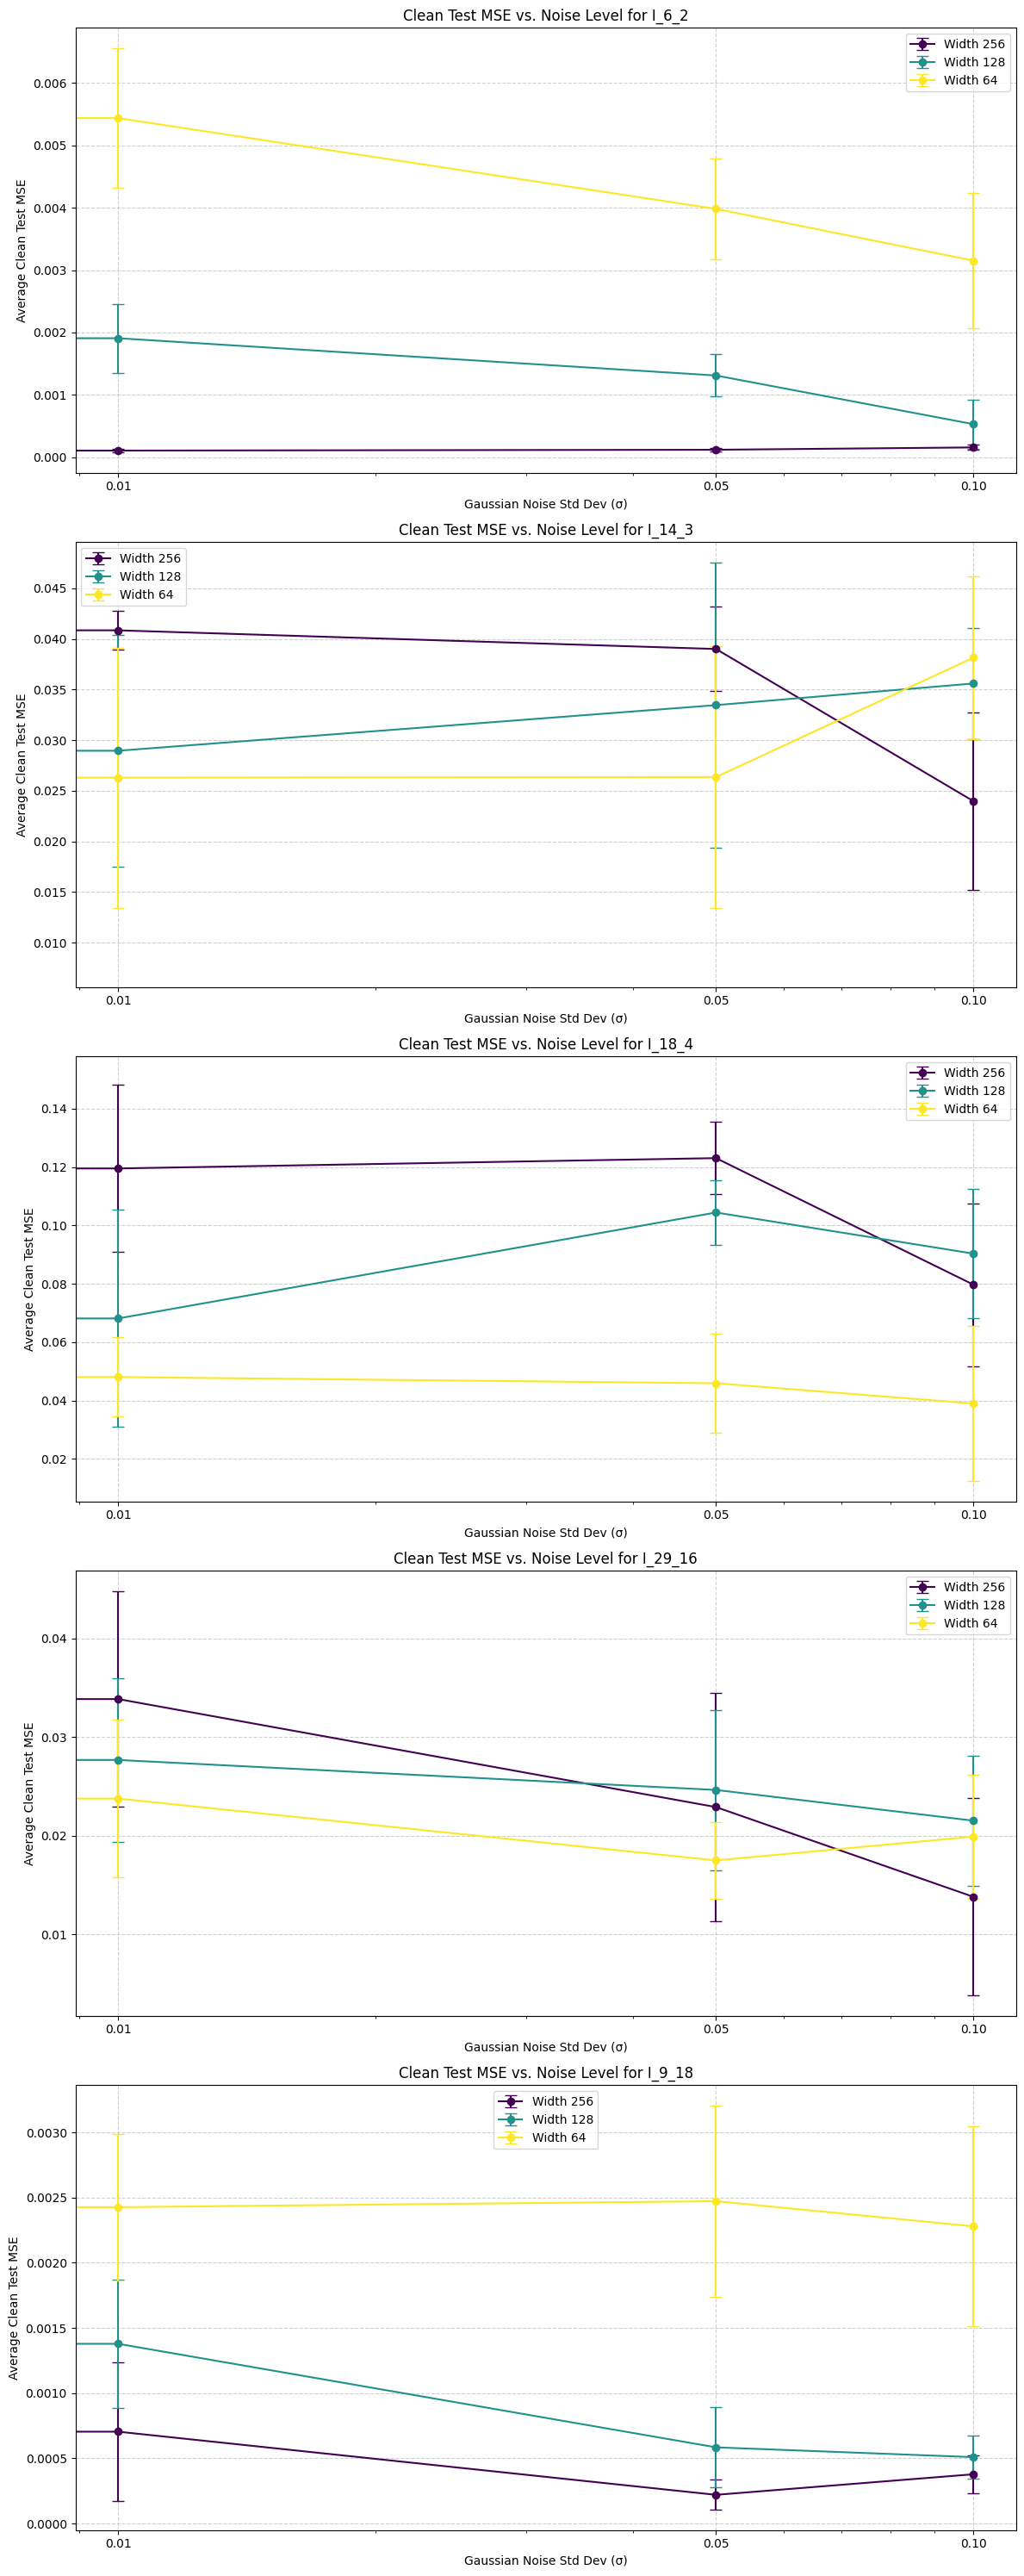

In [ ]:
num_equations = len(all_noise_experiments_results)
mlp_widths = [64, 128, 256]
num_widths = len(mlp_widths)
noise_std_devs = [0, 0.01, 0.05, 0.1] # Standard deviations for Gaussian noise
num_seeds = 5

fig, axes = plt.subplots(num_equations, 1, figsize=(12, 6 * num_equations), squeeze=False)

width_colors = plt.cm.viridis(np.linspace(0, 1, num_widths))

print("\n--- Noise Robustness Analysis Summary ---")

for i, (eqn_name, equation_results) in enumerate(all_noise_experiments_results.items()):
    ax = axes[i, 0]
    ax.set_title(f'Clean Test MSE vs. Noise Level for {eqn_name}')
    ax.set_xlabel('Gaussian Noise Std Dev (σ)')
    ax.set_ylabel('Average Clean Test MSE')
    ax.set_xscale('log') # Use log scale for x-axis if noise levels vary significantly
    ax.set_xticks(noise_std_devs) # Ensure all noise levels are marked on x-axis
    ax.get_xaxis().set_major_formatter(plt.FormatStrFormatter('%.2f'))

    for w_idx, (width, noise_level_results) in enumerate(equation_results.items()):
        avg_mses = []
        std_mses = []
        sorted_noise_std_devs = sorted(noise_level_results.keys())

        for noise_std_dev in sorted_noise_std_devs:
            mses = [res['final_test_mse_clean'] for res in noise_level_results[noise_std_dev]]
            avg_mses.append(np.mean(mses))
            std_mses.append(np.std(mses))

            print(f"Equation: {eqn_name}, Width: {width}, Noise Std Dev: {noise_std_dev:.2f} | Avg Clean Test MSE: {np.mean(mses):.6f} ± {np.std(mses):.6f}")

        # Plot with error bars (standard deviation)
        ax.errorbar(sorted_noise_std_devs, avg_mses, yerr=std_mses, capsize=5, marker='o',
                    linestyle='-', color=width_colors[w_idx], label=f'Width {width}')

    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()